In [1]:
import pandas as pd 
df=pd.read_csv("College_Admission.csv")
df.head()

,student_id,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility
0,250.99,17,other,general,odisha,management,cet,30,95.58,2,0.387,admitted,yes
1,250.99,20,other,ews,gujarat,agriculture,none,0,75.45,2,0.221,rejected,no
2,250.99,19,female,sc,uttar pradesh,pharmacy,cet,120,75.36,10,0.446,rejected,no
3,250.99,18,male,ews,meghalaya,arts,cet,179,52.49,2,0.174,admitted,no
4,250.99,18,male,sc,rajasthan,engineering,jee,295,92.48,7,0.634,admitted,yes


In [2]:
df.isnull().sum()

student_id                 0
age                        0
gender                     0
category                   0
state                      0
preferred_stream           0
entrance_exam              0
entrance_score             0
board_percentage           0
extracurricular_score      0
admission_probability      0
admission_status           0
scholarship_eligibility    0
dtype: int64

In [3]:
df.describe()

,student_id,age,entrance_score,board_percentage,extracurricular_score,admission_probability
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,18.492440,77.879760,75.028014,4.990920,0.323997
std,7212.732314,1.116205,120.356125,14.438767,3.158942,0.142427
min,250.990000,17.000000,0.000000,50.440000,0.000000,0.041990
25%,6250.750000,17.000000,0.000000,62.550000,2.000000,0.219000
50%,12500.500000,18.000000,20.000000,75.070000,5.000000,0.319000
75%,18750.250000,19.000000,126.000000,87.640000,8.000000,0.419000
max,24750.010000,20.000000,634.000000,99.530000,10.000000,0.731010


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   student_id               25000 non-null  float64
 1   age                      25000 non-null  int64  
 2   gender                   25000 non-null  object 
 3   category                 25000 non-null  object 
 4   state                    25000 non-null  object 
 5   preferred_stream         25000 non-null  object 
 6   entrance_exam            25000 non-null  object 
 7   entrance_score           25000 non-null  int64  
 8   board_percentage         25000 non-null  float64
 9   extracurricular_score    25000 non-null  int64  
 10  admission_probability    25000 non-null  float64
 11  admission_status         25000 non-null  object 
 12  scholarship_eligibility  25000 non-null  object 
dtypes: float64(3), int64(3), object(7)
memory usage: 2.5+ MB
None


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df['Unique_ID'] = range(1, len(df) +1)

In [7]:
df.head()

,student_id,age,gender,category,state,preferred_stream,entrance_exam,entrance_score,board_percentage,extracurricular_score,admission_probability,admission_status,scholarship_eligibility,Unique_ID
0,250.99,17,other,general,odisha,management,cet,30,95.58,2,0.387,admitted,yes,1
1,250.99,20,other,ews,gujarat,agriculture,none,0,75.45,2,0.221,rejected,no,2
2,250.99,19,female,sc,uttar pradesh,pharmacy,cet,120,75.36,10,0.446,rejected,no,3
3,250.99,18,male,ews,meghalaya,arts,cet,179,52.49,2,0.174,admitted,no,4
4,250.99,18,male,sc,rajasthan,engineering,jee,295,92.48,7,0.634,admitted,yes,5


In [8]:
df.columns

Index(['student_id', 'age', 'gender', 'category', 'state', 'preferred_stream',
       'entrance_exam', 'entrance_score', 'board_percentage',
       'extracurricular_score', 'admission_probability', 'admission_status',
       'scholarship_eligibility', 'Unique_ID'],
      dtype='object')

In [9]:
cat_columns =[ 'gender', 'category', 'state', 'preferred_stream',
       'entrance_exam', 'admission_status',
       'scholarship_eligibility']
for col in cat_columns: 
    df[col] = df[col].astype('category')

print('New Unique Id Added and Data is ready for analysis')

New Unique Id Added and Data is ready for analysis


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   student_id               25000 non-null  float64 
 1   age                      25000 non-null  int64   
 2   gender                   25000 non-null  category
 3   category                 25000 non-null  category
 4   state                    25000 non-null  category
 5   preferred_stream         25000 non-null  category
 6   entrance_exam            25000 non-null  category
 7   entrance_score           25000 non-null  int64   
 8   board_percentage         25000 non-null  float64 
 9   extracurricular_score    25000 non-null  int64   
 10  admission_probability    25000 non-null  float64 
 11  admission_status         25000 non-null  category
 12  scholarship_eligibility  25000 non-null  category
 13  Unique_ID                25000 non-null  int64   
dtypes: cat

### EDA(Exploratory Data Analysis)

In [11]:
import matplotlib.pyplot as plt 
import seaborn as sns

**Q1. Kaunse Stream mein sabse zyada competition hai?**

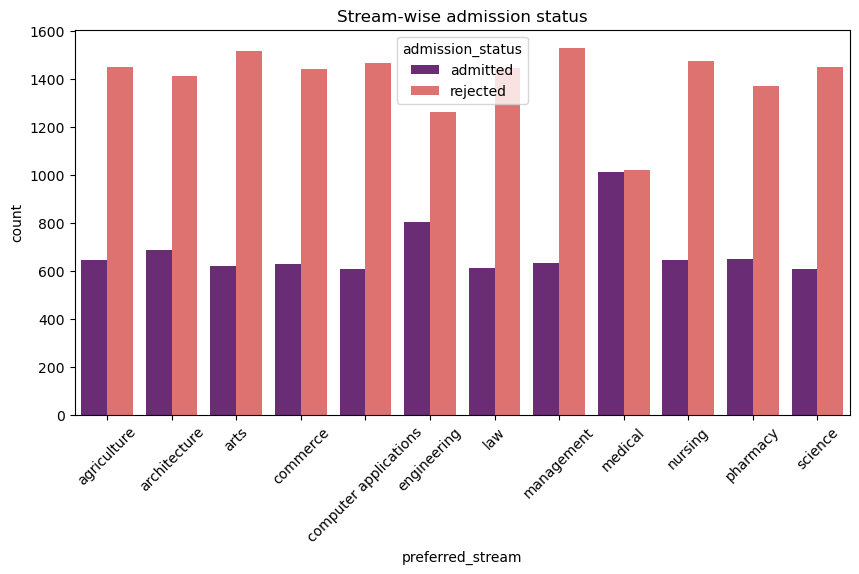

In [12]:
plt.figure(figsize=(10,5))
sns.countplot(data=df, x='preferred_stream', hue='admission_status', palette='magma')
plt.title('Stream-wise admission status')
plt.xticks(rotation=45)
plt.show()

**Q2. Entrance Exam ka impact Probability par kya hai?**

<function matplotlib.pyplot.show(close=None, block=None)>

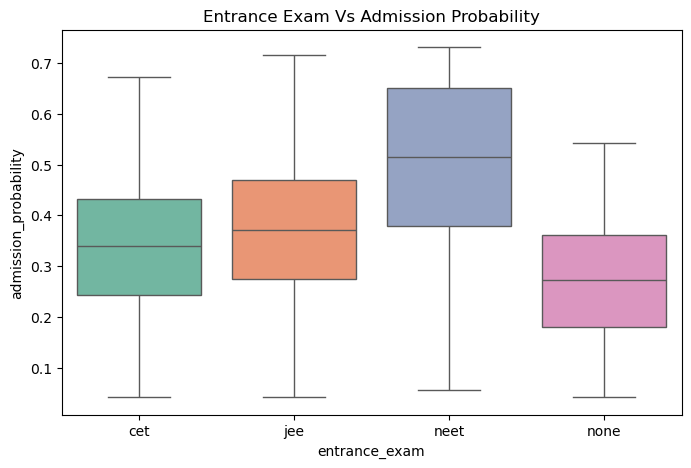

In [19]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='entrance_exam', y='admission_probability',hue='entrance_exam', palette='Set2')
plt.title('Entrance Exam Vs Admission Probability')
plt.show

In [22]:
def get_tier(pct):
    if pct >= 90: return 'Elite (90%+)'
    elif pct >= 75: return 'High (75-90%)'
    elif pct >= 60: return 'Average (60-75%)'
    else: return 'Below Average (<60%)'

# Ye column banana zaroori hai
df['performance_tier'] = df['board_percentage'].apply(get_tier)
df.to_csv('Cleaned_College_Admission_Final.csv', index=False)